# Politeness Intensity Representation in Gemma 2 2B

**Research question:** Does the model encode politeness as a graded, linear spectrum in its internal representations, or as discrete, unordered categories?

**Setup:**

| | |
|---|---|
| **Model** | `google/gemma-2-2b` (base, completion mode) |
| **Trait** | politeness — three levels: `negative` / `neutral` / `positive` |
| **Focal layer** | 13 (midpoint of 26 total; mid-network layers typically encode abstract semantics) |
| **Data** | machine-generated paraphrases, filtered by a blind intensity judge (`data/v2/politeness/accepted.jsonl`) |

**Core hypothesis:** If the model treats politeness as a continuous 1D scale, then the activation-space vector from `negative → neutral` centroids should be *parallel* to the vector from `neutral → positive` centroids. We test this geometrically and then quantify the degree of linearity with several complementary metrics.

## 1. Setup

Load dependencies and internal library modules:

- `data_typing` — typed `Sample` dataclass and JSONL loading utilities
- `representations` — forward-pass helpers that extract hidden-state activations at a given layer
- `analysis` — difference vectors, cosine similarity matrix, and plotting

In [ ]:
import json
import sys
from pathlib import Path

import torch

sys.path.insert(0, str(Path("..").resolve()))  # src/notebooks/ -> src/

from lib.data_typing import Sample, LEVELS, load_accepted
from lib.representations import load_model, extract_activations, extract_activations_multilayer
from lib.analysis import compute_difference_vectors, similarity_matrix, plot_similarity_matrix

### 1.1 Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `MODEL` | `google/gemma-2-2b` | Small enough to run locally; has published Gemma Scope SAEs at every layer |
| `LAYER` | `13` | Mid-network (layers 10–18 are typically where abstract semantic structure peaks) |
| `TRAIT` | `politeness` | 3-level ordinal trait; good test case for linearity since levels have a natural order |
| `ACCEPTED_JSONL` | `data/v2/politeness/accepted.jsonl` | Paraphrases that passed the blind intensity quality gate |

In [ ]:
MODEL   = "google/gemma-2-2b"
LAYER   = 13
TRAIT   = "politeness"
ACCEPTED_JSONL = Path("../../data/v2/politeness/accepted.jsonl")

### 1.2 Data Loading

Each record in the JSONL file represents one accepted paraphrase: a short text rewritten at a specific intensity level (`negative`, `neutral`, or `positive`), confirmed by a blind judge to be distinguishable from the other levels.

**What to check:** counts per level should be roughly balanced (~100+ each). Highly imbalanced groups shift centroid estimates and distort metric comparisons.

In [ ]:
records_raw = []
with ACCEPTED_JSONL.open() as f:
    for line in f:
        line = line.strip()
        if line:
            records_raw.append(json.loads(line))

found = {r["level"] for r in records_raw}
levels_present = [l for l in LEVELS if l in found]
print(f"Loaded {len(records_raw)} accepted paraphrases")
print(f"Levels found (ordered): {levels_present}")
for lvl in levels_present:
    texts = [r["text"] for r in records_raw if r["level"] == lvl]
    print(f"  {lvl}: {len(texts)} items — e.g. '{texts[0][:80]}'")

Loaded 2090 accepted paraphrases
Levels found (ordered): ['negative', 'neutral', 'positive']
  negative: 707 items — e.g. 'Il report è in ritardo, pazienza. Capita a tutti, no? Non assillare, te lo siste'
  neutral: 670 items — e.g. 'Mi scuso per il ritardo nella consegna del report. Farò il possibile per inviarl'
  positive: 713 items — e.g. 'Spero vorrà accettare le mie più sentite scuse per il ritardo del report. Capisc'


### 1.3 Sample Construction

Wrap raw records into typed `Sample` objects with fields: `prompt`, `trait`, `intensity`, `scenario_id`. This is the uniform interface expected by the activation-extraction and analysis functions downstream.

In [ ]:
samples = load_accepted(ACCEPTED_JSONL)
TRAITS_CFG = [{"name": TRAIT, "intensities": levels_present}]

### 1.4 Device Detection

Selects the fastest available backend: CUDA (NVIDIA GPU) → MPS (Apple Silicon) → CPU. All tensor operations run on this device.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {device}")

device: mps


### 1.5 Load Model

Load `google/gemma-2-2b` weights onto the selected device. This is the only slow step (~20 s on MPS/CUDA). The model runs in inference mode — weights are never updated.

In [ ]:
# slow — run once
model, tokenizer = load_model(MODEL, device)

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

## 2. Extracting Activations

For each text sample, we run a forward pass and extract the **residual stream** at layer 13 — the hidden-state tensor immediately after that transformer block, before any further processing.

**Pipeline per sample:**
1. Tokenize → run forward pass → read `hidden_states[layer + 1]` (shape: `[batch, tokens, 2304]`)
2. Mask out padding, BOS, and EOS tokens
3. Mean-pool over the remaining content tokens → one vector per sample of shape `(2304,)`

**Output:** `activations` — a dict mapping `(trait, intensity, scenario_id)` → tensor `(2304,)`.

The norm printed per entry is a quick sanity check: all vectors should have similar norms (~100–300), confirming no degenerate zeros or NaNs.

In [ ]:
activations = extract_activations(samples, model, tokenizer, LAYER, device)

for (trait, intensity, scenario_id), vec in activations.items():
    print(f"  ({trait}, {intensity}, {scenario_id}): shape={vec.shape}, norm={vec.norm():.2f}")

  (politeness, negative, politeness-apology-001): shape=torch.Size([2304]), norm=112.87
  (politeness, neutral, politeness-apology-001): shape=torch.Size([2304]), norm=112.22
  (politeness, positive, politeness-apology-001): shape=torch.Size([2304]), norm=104.14
  (politeness, negative, politeness-apology-004): shape=torch.Size([2304]), norm=140.72
  (politeness, neutral, politeness-apology-004): shape=torch.Size([2304]), norm=150.25
  (politeness, positive, politeness-apology-004): shape=torch.Size([2304]), norm=141.03
  (politeness, negative, politeness-apology-013): shape=torch.Size([2304]), norm=120.11
  (politeness, neutral, politeness-apology-013): shape=torch.Size([2304]), norm=119.12
  (politeness, positive, politeness-apology-013): shape=torch.Size([2304]), norm=108.39
  (politeness, negative, politeness-apology-038): shape=torch.Size([2304]), norm=117.19
  (politeness, neutral, politeness-apology-038): shape=torch.Size([2304]), norm=110.00
  (politeness, positive, politeness-

## 3. Geometric Analysis of the Intensity Ladder

**The linearity hypothesis:** If politeness is represented as a 1D continuous scale in activation space, moving from one level to the next should trace a *straight line* — the direction from `negative` to `neutral` should be parallel to the direction from `neutral` to `positive`.

We test this by computing *difference vectors* between level centroids and measuring their angular alignment.

### 3.1 Difference Vectors

For each ordered pair of intensity levels, we compute:

```
d(A → B) = mean_activation(B) − mean_activation(A)
```

**Three vectors:**
- `negative → neutral`: direction of the first step up the politeness scale
- `neutral → positive`: direction of the second step
- `negative → positive`: the full-span direction (equals the sum of the two if perfectly linear)

**Norm interpretation:** larger norm = greater centroid separation. The ratio between consecutive norms indicates whether the spacing is symmetric (equal steps) or compressed at one end of the scale.

In [ ]:
diffs = compute_difference_vectors(activations, TRAITS_CFG)

for (trait, lo, hi), vec in diffs.items():
    print(f"  {trait}: {lo} -> {hi}  norm={vec.norm():.2f}")

  politeness: neutral -> positive  norm=15.96
  politeness: negative -> neutral  norm=20.88
  politeness: negative -> positive  norm=22.26


### 3.2 Cosine Similarity Between Difference Vectors

Cosine similarity measures the angular alignment between two vectors, independent of their magnitudes:

| Value | Meaning |
|-------|---------|
| `+1.0` | Identical direction → perfect linearity |
| `≈ 0.0` | Orthogonal → the two transitions point in unrelated directions |
| `−1.0` | Opposite direction → the scale reverses |

**Key cell to read:** off-diagonal entry for `(negative→neutral) vs (neutral→positive)`. Under the linearity hypothesis this should be near +1.

**Also check:** `(negative→positive)` vs either partial vector. If linear, the full-span vector is the sum of the two steps and should align with both.

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

labels, matrix = similarity_matrix(diffs)

print("Cosine similarity matrix:")
header = f"{'':>25}" + "".join(f"{l:>27}" for l in labels)
print(header)
for i, li in enumerate(labels):
    row = f"{li:>25}" + "".join(f"{matrix[i, j]:>27.4f}" for j in range(len(labels)))
    print(row)

if len(labels) >= 2:
    print(f"\nKey number — cosine similarity {labels[0]} vs {labels[1]}: {matrix[0, 1]:.4f}")
    print("  +1 = same direction (linear), -1 = opposite, ~0 = unrelated")

Cosine similarity matrix:
                         politeness:positive-neutralpoliteness:neutral-negativepoliteness:positive-negative
politeness:positive-neutral                     1.0000                    -0.2946                     0.4499
politeness:neutral-negative                    -0.2946                     1.0000                     0.7202
politeness:positive-negative                     0.4499                     0.7202                     1.0000

Key number — cosine similarity politeness:positive-neutral vs politeness:neutral-negative: -0.2946
  +1 = same direction (linear), -1 = opposite, ~0 = unrelated


### 3.3 Cosine Similarity Heatmap

Color encodes cosine similarity: red (−1) → yellow (0) → green (+1).

**How to read it:**
- The diagonal is always 1.0 (self-similarity) — ignore it.
- **Off-diagonal green** → the corresponding pair of transition directions are aligned → consistent with a linear axis.
- **Off-diagonal yellow or red** → transition directions diverge → the trait is not encoded on a single ray.

A near-zero off-diagonal would indicate that the `negative→neutral` and `neutral→positive` transitions point in largely independent directions in the dense residual stream at this layer.

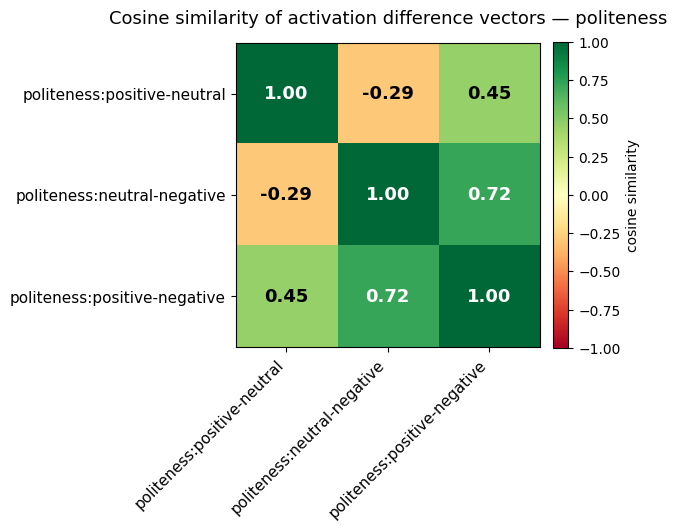

In [ ]:
n = len(labels)
cell = 2.2
fig, ax = plt.subplots(figsize=(max(6, n * cell), max(6, n * cell)))
im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdYlGn")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i, j in itertools.product(range(n), range(n)):
    color = "white" if abs(matrix[i, j]) > 0.65 else "black"
    ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
            fontsize=13, fontweight="bold", color=color)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("cosine similarity", fontsize=10)
ax.set_title(f"Cosine similarity of activation difference vectors — {TRAIT}", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

### 3.4 Layer Sweep: Direction Alignment Across Layers 8–22

The cosine similarity between difference vectors may vary by layer. This sweeps layers 8–22, re-extracting activations (using the cached multilayer pass) and recomputing the similarity matrix at each layer.

**Three curves plotted** (one per pair of transition directions):
- `positive−neutral` vs `neutral−negative` — the core linearity test
- `positive−negative` vs each partial vector — consistency of the full-span direction

**What to look for:**
- A peak or plateau in the adjacent-step curve marks the layer where the representation is most linear.
- A flat, low profile suggests no single layer organizes the trait as a 1D line.
- Consistency between the two `vs positive−negative` curves confirms the full span is well-defined.

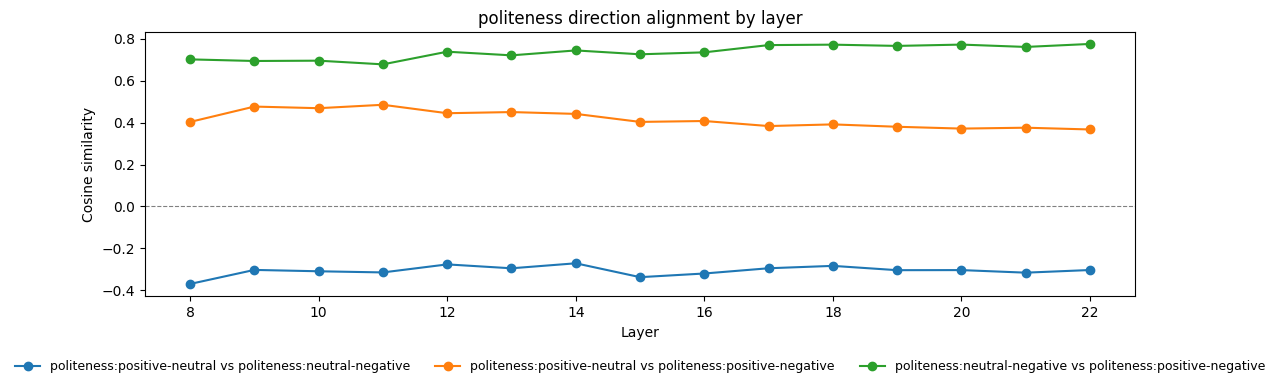

In [ ]:
sweep_layers = list(range(8, 23))

# One forward pass per batch, all layers captured at once.
acts_all = extract_activations_multilayer(samples, model, tokenizer, sweep_layers, device)

pair_indices = list(itertools.combinations(range(len(labels)), 2))
pair_sims = {pair: [] for pair in pair_indices}

for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    d = compute_difference_vectors(acts_layer, TRAITS_CFG)
    _, m = similarity_matrix(d)
    for pair in pair_indices:
        pair_sims[pair].append(m[pair[0], pair[1]])

fig, ax = plt.subplots(figsize=(11, 4.4))
for (i, j), sims in pair_sims.items():
    ax.plot(sweep_layers, sims, marker="o", linewidth=1.5, label=f"{labels[i]} vs {labels[j]}")

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"{TRAIT} direction alignment by layer")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False, fontsize=9)
fig.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.28)
plt.show()

### 3.5 Metric-Aware Re-Analysis: Whitening, Anisotropy, and Disattenuation

§3.2 reports the adjacent-step cosine using the ordinary (Euclidean) dot product on the raw residual stream. That number is **not coordinate-free**: a cosine depends entirely on *which inner product* you measure it with, and the residual stream's native coordinate system is a poor choice of ruler. Here we recompute the difference-vector cosine matrix under three alternative inner products, then correct each for estimation noise.

#### Why the inner product matters

A cosine is `⟨d₁,d₂⟩ / (‖d₁‖‖d₂‖)`. The Euclidean inner product `⟨x,y⟩ = xᵀy` implicitly assumes **every one of the 2304 residual dimensions is equally important and mutually orthogonal** — neither holds for a transformer's residual stream. A general inner product is `⟨x,y⟩_M = xᵀM y` for a positive-definite `M`; equivalently, transform every vector by a *whitening matrix* `W` (with `M = WᵀW`) and take the ordinary dot product in the new coordinates. Different `W` answer different questions:

| Space | Whitening `W` | Question it answers |
|---|---|---|
| **Euclidean (raw)** | `I` | Are the steps aligned in the model's native coordinates? (the §3.2 default) |
| **Anisotropy-corrected** | `diag(1/σ)` | …after removing "rogue dimensions" — a few coordinates whose huge variance dominates every raw cosine |
| **Park causal** | `Cov(γ)^(−1/2)` | …in the inner product under which *causally independent* concepts come out orthogonal |
| **Mahalanobis / LDA** | `Σ_within^(−1/2)` | …after discounting the directions the model varies along *within* a fixed politeness level (angles measured in units of noise) |

#### The three corrections

**1 · Anisotropy correction.** Transformer residual streams are strongly *anisotropic*: a few dimensions carry orders of magnitude more variance than the rest, and those "rogue dimensions" dominate any raw cosine (Timkey & van Schijndel, 2021). Dividing each dimension by its standard deviation — `W = diag(1/σ)`, a *diagonal* whitening, equivalent to z-scoring every coordinate — puts all dimensions on equal footing. It is the cheapest correction and the standard fix for cosine artifacts in embedding spaces.

**2 · Park causal whitening.** Park, Choe & Veitch (2024) show the residual stream has a *preferred* non-Euclidean geometry: the **causal inner product** `⟨x,y⟩_C = xᵀ Cov(γ)⁻¹ y`, where `Cov(γ)` is the covariance of the model's **unembedding vectors** (one per vocabulary token). Under it, concepts that vary independently (`French⇒English` vs `male⇒female`) come out orthogonal — making it the natural ruler for asking whether two *transitions* are aligned. We whiten by `W = Cov(γ)^(−1/2)`. *(Park's theory is stated for the unembedding/word space; `Cov(γ)^(−1/2)` is exactly the map that carries context-side representations into that frame. Applying it to a mid-layer residual is an approximation — the model also applies a final RMSNorm before unembedding — but a faithful and citable one.)*

**3 · Mahalanobis / LDA whitening.** The two whitenings above ignore the labels; this one uses them. `Σ_within` is the pooled covariance of activations **within** each politeness level — i.e. the variation that is *not* politeness, the noise. Whitening by `W = Σ_within^(−1/2)` rescales space so one unit = one standard deviation of within-level noise; a cosine here measures alignment in *discriminability* units (the geometry a linear discriminant uses). Because `Σ_within` is a 2304×2304 matrix estimated from a few hundred samples it is rank-deficient, so we regularize it with **Ledoit–Wolf shrinkage** before inverting.

#### Disattenuation — correcting for estimation noise

This step is *orthogonal* to the choice of inner product. Each step vector is a centroid difference estimated from a finite sample: `d̂ = d_true + noise`. The noise is uncorrelated between two different step vectors, so it **drags any cosine between them toward 0** — a near-orthogonal result can simply mean "too noisy to tell."

We quantify the noise with **split-half reliability**: split the scenarios in half, estimate each step vector independently on each half, and take the cosine of the two estimates of the *same* vector. A perfectly-estimated vector self-correlates at 1.0; a noisy one well below. The Spearman–Brown formula rescales the half-sample reliability `r½` to the full-sample reliability `R = 2r½ / (1 + r½)`. The **disattenuated cosine** then divides the noise back out:

> `cos_true(d₁,d₂)  ≈  cos_obs(d₁,d₂) / √(R₁ · R₂)`

If raw and disattenuated cosines agree, any observed near-orthogonality is *real*. If disattenuation lifts the cosine substantially, the raw value was partly a noise artifact and the true geometry is more linear than §3.2 suggested.

In [ ]:
# §3.5 — Build the four inner-product spaces (whitening matrices)
from sklearn.covariance import LedoitWolf

D = next(iter(activations.values())).shape[0]


def inv_sqrt_psd(cov, rcond=1e-6):
    """Symmetric inverse square root M^(-1/2) of a PSD matrix.

    Eigenvalues are floored at rcond * max_eigenvalue before inversion, so a
    rank-deficient covariance still yields a finite, well-conditioned whitener.
    """
    cov = 0.5 * (cov + cov.T)
    evals, evecs = np.linalg.eigh(cov)
    evals = np.clip(evals, rcond * float(evals.max()), None)
    return (evecs * evals ** -0.5) @ evecs.T


# All sample activations, float64 for numerically stable whitening.
acts_f64 = {k: v.numpy().astype(np.float64) for k, v in activations.items()}
X_all = np.stack(list(acts_f64.values()))                       # (N, D)

# 1 - Euclidean: identity (reproduces §3.2).
W_eucl = np.eye(D)

# 2 - Anisotropy correction: diagonal whitening (z-score each dimension).
sigma = X_all.std(axis=0)
W_aniso = np.diag(1.0 / np.clip(sigma, 1e-8, None))

# 3 - Park causal whitening: inverse-sqrt of the unembedding covariance.
# Cov(gamma) is accumulated over the whole vocabulary in chunks to bound memory.
U = model.get_output_embeddings().weight.detach()               # (V, D), on device
Vsz, CHUNK = U.shape[0], 16384
gram = torch.zeros(D, D, dtype=torch.float64)
col_sum = torch.zeros(D, dtype=torch.float64)
for s in range(0, Vsz, CHUNK):
    blk = U[s:s + CHUNK].to("cpu", torch.float32)
    gram += (blk.T @ blk).double()
    col_sum += blk.sum(0).double()
mean_u = col_sum / Vsz
cov_unembed = (gram / Vsz - torch.outer(mean_u, mean_u)).numpy()
W_park = inv_sqrt_psd(cov_unembed)

# 4 - Mahalanobis / LDA whitening: inverse-sqrt of the pooled within-level covariance.
within = np.concatenate([
    Xl - Xl.mean(axis=0, keepdims=True)
    for Xl in (np.stack([acts_f64[k] for k in acts_f64 if k[1] == lvl])
               for lvl in levels_present)
])
lw = LedoitWolf(assume_centered=True).fit(within)
W_lda = inv_sqrt_psd(lw.covariance_)

SPACES = {
    "Euclidean (raw)":      W_eucl,
    "Anisotropy-corrected": W_aniso,
    "Park causal":          W_park,
    "Mahalanobis / LDA":    W_lda,
}
print(f"hidden dim D = {D}   vocabulary V = {Vsz}   samples N = {len(acts_f64)}")
print(f"Ledoit-Wolf shrinkage applied to within-level covariance: {lw.shrinkage_:.4f}")
for name, W in SPACES.items():
    print(f"  {name:<22} whitener ready  (Frobenius norm = {np.linalg.norm(W):.4g})")

hidden dim D = 2304   vocabulary V = 256000   samples N = 700
Ledoit-Wolf shrinkage applied to within-level covariance: 0.0217
  Euclidean (raw)        whitener ready  (Frobenius norm = 48)
  Anisotropy-corrected   whitener ready  (Frobenius norm = 63.81)
  Park causal            whitener ready  (Frobenius norm = 4665)
  Mahalanobis / LDA      whitener ready  (Frobenius norm = 292)


In [ ]:
# §3.5 — Cosine matrices and noise-disattenuated cosines in each space
N_REL_SPLITS = 300       # random scenario half-splits for the reliability estimate
REL_SEED = 0


def transform_acts(acts, W):
    """Apply whitening W to every activation vector."""
    return {k: torch.from_numpy(W @ v) for k, v in acts.items()}


def diff_dict(acts):
    """(trait, lo, hi) -> difference vector, via the §3.1 paired-scenario estimator."""
    d = compute_difference_vectors(acts, TRAITS_CFG)
    return {k: d[k].numpy() for k in d}


def cosine_matrix(vecs):
    """All-pairs cosine similarity over a list of vectors."""
    M = np.stack([v / np.linalg.norm(v) for v in vecs])
    return np.clip(M @ M.T, -1.0, 1.0)


def full_reliability(acts, canon_keys, n_splits=N_REL_SPLITS, seed=REL_SEED):
    """Spearman-Brown-corrected full-sample reliability of each step vector.

    Repeatedly splits the *scenarios* in half, recomputes each difference vector
    independently on each half, and averages the cosine between the two
    same-vector estimates -> half-sample reliability r_half. Spearman-Brown then
    rescales it to the full-sample reliability R = 2*r_half / (1 + r_half).
    """
    rng = np.random.default_rng(seed)
    sids = sorted({k[2] for k in acts})
    acc = np.zeros(len(canon_keys))
    cnt = np.zeros(len(canon_keys))
    for _ in range(n_splits):
        rng.shuffle(sids)
        cut = len(sids) // 2
        a_sids, b_sids = set(sids[:cut]), set(sids[cut:])
        da = diff_dict({k: v for k, v in acts.items() if k[2] in a_sids})
        db = diff_dict({k: v for k, v in acts.items() if k[2] in b_sids})
        for i, key in enumerate(canon_keys):
            if key in da and key in db:
                x, y = da[key], db[key]
                acc[i] += float((x / np.linalg.norm(x)) @ (y / np.linalg.norm(y)))
                cnt[i] += 1
    r_half = acc / np.maximum(cnt, 1)
    R_full = 2.0 * r_half / (1.0 + r_half)
    return r_half, np.clip(R_full, 1e-3, 1.0)


def disattenuate(cosmat, R_full):
    """Divide each off-diagonal cosine by sqrt(R_i * R_j)."""
    R = np.sqrt(R_full)
    out = np.clip(cosmat / np.outer(R, R), -1.0, 1.0)
    np.fill_diagonal(out, 1.0)
    return out


space_results = {}
canon_keys = None
for name, W in SPACES.items():
    acts_W = transform_acts(acts_f64, W)
    dd = diff_dict(acts_W)
    if canon_keys is None:
        canon_keys = list(dd.keys())
    labels_S = [f"{hi}-{lo}" for (_, lo, hi) in canon_keys]
    cos_raw = cosine_matrix([dd[k] for k in canon_keys])
    r_half, R_full = full_reliability(acts_W, canon_keys)
    cos_dis = disattenuate(cos_raw, R_full)
    space_results[name] = dict(labels=labels_S, cos_raw=cos_raw, cos_dis=cos_dis,
                               r_half=r_half, R_full=R_full)

# Summary table: the adjacent-step cosine (positions 0 and 1 of the matrix).
labels_S = space_results["Euclidean (raw)"]["labels"]
print(f"Adjacent-step alignment:  ({labels_S[1]})  vs  ({labels_S[0]})")
print(f"(Euclidean raw cos should reproduce the §3.2 value of -0.0818)\n")
hdr = f"{'space':<22}{'raw cos':>10}{'disatt cos':>13}{'R[0]':>9}{'R[1]':>9}{'R[2]':>9}"
print(hdr)
print("-" * len(hdr))
for name, r in space_results.items():
    print(f"{name:<22}{r['cos_raw'][0, 1]:>10.4f}{r['cos_dis'][0, 1]:>13.4f}"
          f"{r['R_full'][0]:>9.3f}{r['R_full'][1]:>9.3f}{r['R_full'][2]:>9.3f}")
print(f"\nR[0]={labels_S[0]}   R[1]={labels_S[1]}   R[2]={labels_S[2]}"
      f"   (full-sample reliability of each step vector)")

Adjacent-step alignment:  (neutral-negative)  vs  (positive-neutral)
(Euclidean raw cos should reproduce the §3.2 value of -0.0818)

space                    raw cos   disatt cos     R[0]     R[1]     R[2]
------------------------------------------------------------------------
Euclidean (raw)          -0.2946      -0.2996    0.980    0.987    0.988
Anisotropy-corrected     -0.0163      -0.0168    0.965    0.976    0.984
Park causal              -0.2456      -0.2500    0.981    0.984    0.987
Mahalanobis / LDA        -0.0886      -0.0899    0.980    0.990    0.993

R[0]=positive-neutral   R[1]=neutral-negative   R[2]=positive-negative   (full-sample reliability of each step vector)


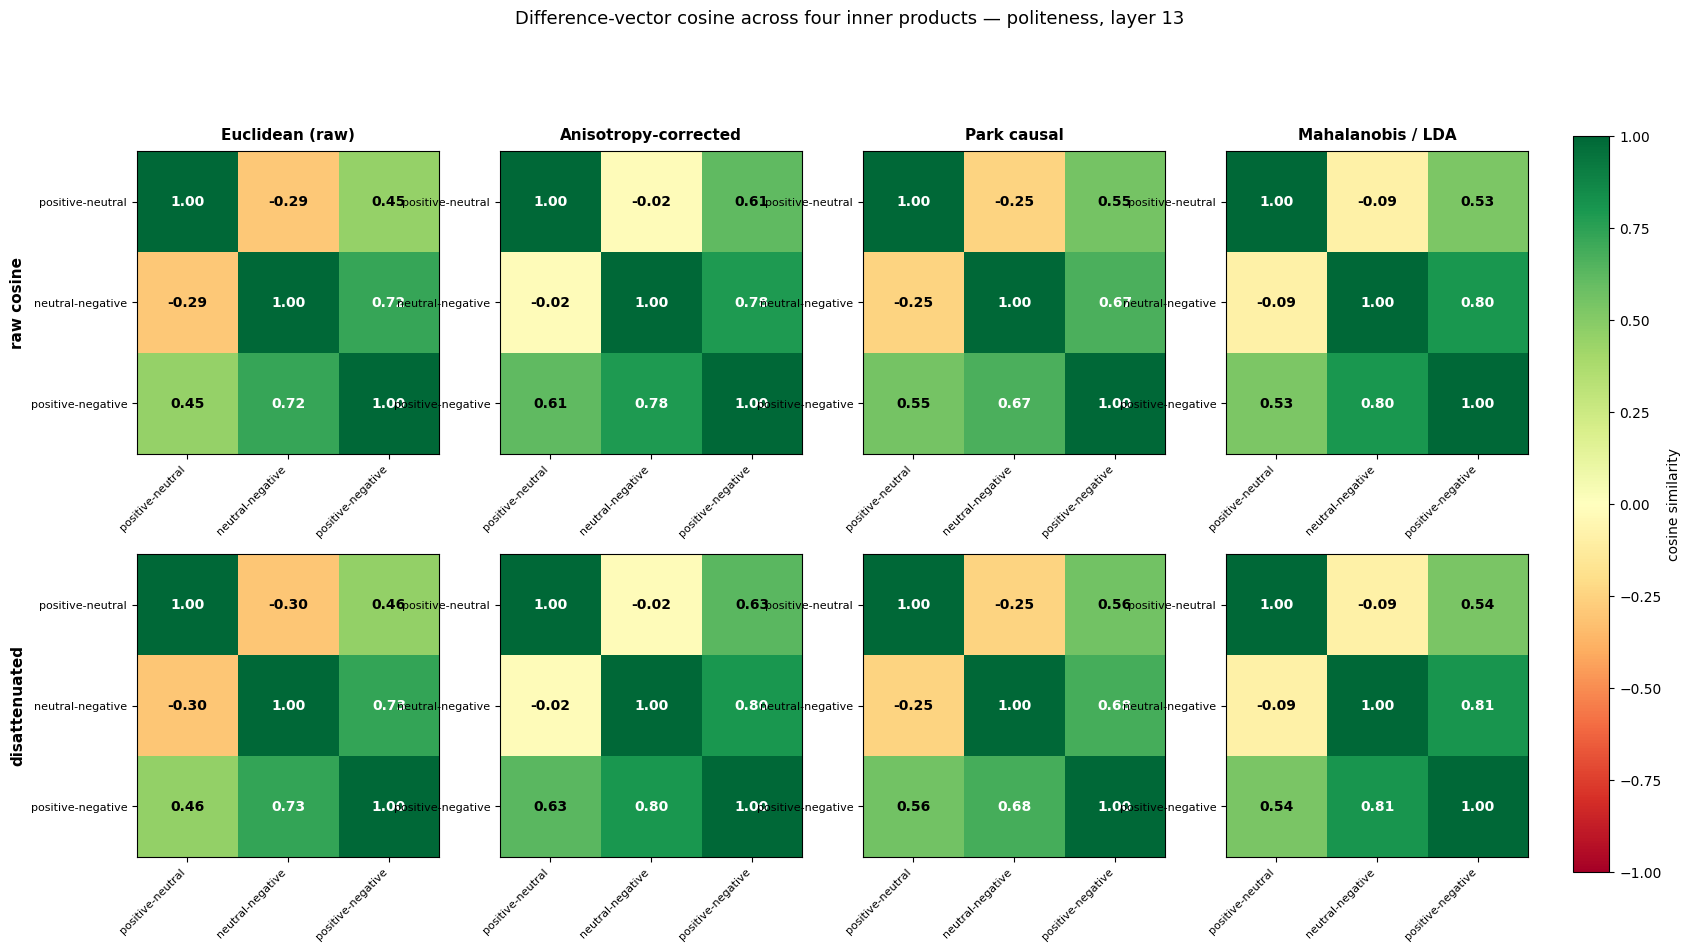

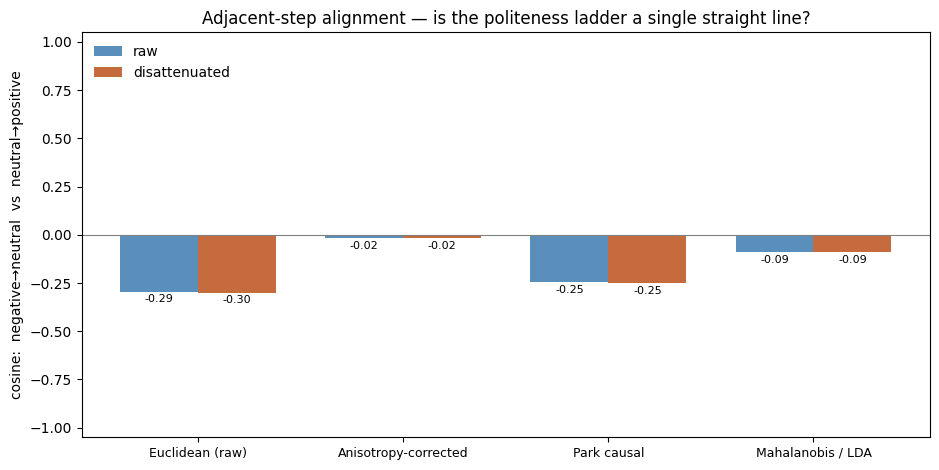

In [ ]:
# §3.5 — Visual comparison across the four inner products
order = list(SPACES)
labels_S = space_results[order[0]]["labels"]
n = len(labels_S)

fig, axes = plt.subplots(2, 4, figsize=(19, 9.6))
for col, name in enumerate(order):
    r = space_results[name]
    for row, (mat, tag) in enumerate([(r["cos_raw"], "raw cosine"),
                                      (r["cos_dis"], "disattenuated")]):
        ax = axes[row, col]
        im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdYlGn")
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(labels_S, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(labels_S, fontsize=8)
        for i, j in itertools.product(range(n), range(n)):
            c = "white" if abs(mat[i, j]) > 0.65 else "black"
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=c)
        if row == 0:
            ax.set_title(name, fontsize=11, fontweight="bold", pad=8)
        if col == 0:
            ax.set_ylabel(tag, fontsize=11, fontweight="bold")
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.03,
             label="cosine similarity")
fig.suptitle(f"Difference-vector cosine across four inner products — {TRAIT}, layer {LAYER}",
             fontsize=13, y=1.01)
plt.show()

# Focused comparison: the adjacent-step cosine, raw vs disattenuated.
raw_vals = [space_results[s]["cos_raw"][0, 1] for s in order]
dis_vals = [space_results[s]["cos_dis"][0, 1] for s in order]
x = np.arange(len(order)); bw = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.8))
b1 = ax.bar(x - bw / 2, raw_vals, bw, label="raw", color="#5A8FBB")
b2 = ax.bar(x + bw / 2, dis_vals, bw, label="disattenuated", color="#C66B3D")
ax.bar_label(b1, fmt="%.2f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.2f", fontsize=8, padding=2)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(order, fontsize=9)
ax.set_ylim(-1.05, 1.05)
ax.set_ylabel("cosine:  negative→neutral  vs  neutral→positive")
ax.set_title("Adjacent-step alignment — is the politeness ladder a single straight line?")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

#### How to read §3.5

Focus on the off-diagonal **`negative→neutral` vs `neutral→positive`** entry — the adjacent-step cosine reported in §3.2 — and compare it across the four columns and between the **raw** (top) and **disattenuated** (bottom) rows. The bar chart isolates exactly this number.

- **Stays near 0 in all four spaces and survives disattenuation** → the near-orthogonality is a genuine geometric fact: the politeness ladder is *not* one straight line, no matter how angles are measured or how much noise is removed.
- **Jumps toward +1 under Park or Mahalanobis whitening** → the Euclidean value was an artifact of the raw-coordinate ruler; the steps *are* aligned once the space is measured in a model-appropriate (Park) or noise-aware (Mahalanobis) geometry.
- **Disattenuation lifts it substantially** → the centroids were too noisy to resolve the alignment. The `R` columns in the table quantify this: `R ≈ 1` means a step vector is well-estimated, `R ≪ 1` means it is dominated by sampling noise — in which case *any* cosine involving it (here and in §3.2) is only a lower bound on the true alignment.

The Euclidean **disattenuated** value is the direct, noise-corrected successor to the §3.2 headline number; the other three columns then ask whether that conclusion is also robust to the choice of inner product.

## 4. Null Distribution Baseline (Disabled)

*These cells are commented out. Re-enable to run the statistical baseline.*

**Purpose:** establish an empirical floor for cosine similarity. In a high-dimensional space, random vectors are nearly orthogonal by construction — but difference vectors computed from small sets of random texts might still show non-trivial alignment purely by chance.

**Method:**
1. Fetch ~60 text snippets from the 20 Newsgroups corpus (semantically unrelated to politeness).
2. Extract activations and form random vector differences (random pairing).
3. Compute cosine similarity between 200 such random pairs.
4. Report: mean, std, q05, q95, q99 of the null distribution.

**How to use the result:** if observed politeness cosines exceed the 99th percentile of the null, the geometric structure cannot be explained by chance alignment in the ambient space.

In [ ]:
#import random as _random
#from sklearn.datasets import fetch_20newsgroups
#
#WIKI_N = 60          # random text snippets to use as a null baseline
#WIKI_PAIRS = 200     # null cosine samples
#WIKI_SEED = 7
#
## 20 Newsgroups is sklearn-native (already a dep), ~14MB, cached after first call.
## We strip headers/footers/quotes so what's left is plain prose.
#_ds = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
#_rng = _random.Random(WIKI_SEED)
#_candidates = [t.strip().replace('\n', ' ') for t in _ds.data
#               if t and 20 <= len(t.split()) <= 200]
#_rng.shuffle(_candidates)
#wiki_texts = _candidates[:WIKI_N]
#print(f'fetched {len(wiki_texts)} text snippets')
#print('example:', wiki_texts[0][:140])

In [ ]:
#wiki_samples = [
#    Sample(prompt=t, trait='wiki', intensity='rand', scenario_id=f'wiki-{i:03d}')
#    for i, t in enumerate(wiki_texts)
#]
#wiki_acts_dict = extract_activations(wiki_samples, model, tokenizer, LAYER, device)
#wiki_vecs = [wiki_acts_dict[('wiki', 'rand', f'wiki-{i:03d}')] for i in range(len(wiki_texts))]
#print(f'wiki activations: n={len(wiki_vecs)}, dim={tuple(wiki_vecs[0].shape)}')

In [ ]:
#from scipy.spatial.distance import cosine as _cos
#
#rng = _random.Random(WIKI_SEED)
#null_cosines = []
#for _ in range(WIKI_PAIRS):
#    a, b, c, d = rng.sample(range(len(wiki_vecs)), 4)
#    diff1 = (wiki_vecs[a] - wiki_vecs[b]).numpy()
#    diff2 = (wiki_vecs[c] - wiki_vecs[d]).numpy()
#    null_cosines.append(1.0 - _cos(diff1, diff2))
#
#null_arr = np.array(null_cosines)
#print(f'null cosine distribution (n={len(null_arr)}):')
#print(f'  mean={null_arr.mean():.4f}  std={null_arr.std():.4f}')
#print(f'  q05={np.quantile(null_arr, 0.05):.4f}  q95={np.quantile(null_arr, 0.95):.4f}  q99={np.quantile(null_arr, 0.99):.4f}')
#
#print('\nPoliteness off-diagonal cosines vs null:')
#for i in range(len(labels)):
#    for j in range(i + 1, len(labels)):
#        v = matrix[i, j]
#        p_emp = float((null_arr >= v).mean())
#        print(f'  {labels[i]:>22} vs {labels[j]:<22} cos={v:+.4f}  p(null>=obs)={p_emp:.4f}')

### 4.1 Null vs. Observed

Overlay the null distribution histogram with vertical lines at the observed politeness cosines.

**Reading the plot:**
- Gray bars = null distribution (random text pairs).
- Colored vertical lines = observed cosine for each transition pair.
- Lines to the far right of the histogram tail → alignment is statistically meaningful.
- Lines buried in the histogram bulk → indistinguishable from noise at that layer.

In [ ]:
#fig, ax = plt.subplots(figsize=(9, 4.4))
#ax.hist(null_arr, bins=40, color='lightgray', edgecolor='gray', label='Wikipedia null pairs')
#_colors = plt.cm.tab10(np.linspace(0, 1, 10))
#_k = 0
#for i in range(len(labels)):
#    for j in range(i + 1, len(labels)):
#        ax.axvline(matrix[i, j], color=_colors[_k % 10], linewidth=2,
#                   label=f'{labels[i]} vs {labels[j]}: {matrix[i, j]:+.2f}')
#        _k += 1
#ax.axvline(0, color='black', linewidth=0.7, linestyle=':')
#ax.set_xlabel('cosine similarity of difference vectors')
#ax.set_ylabel('count (null pairs)')
#ax.set_title(f'Politeness vs random-Wikipedia null distribution — layer {LAYER}')
#ax.legend(fontsize=8, loc='upper left')
#plt.tight_layout()
#plt.show()

## 5. Formal Linearity Metrics

Section 3 tested whether *centroids* fall on a line (using cosine similarity between difference vectors). This section tests whether the **full distribution** of individual sample activations is linearly ordered — a stricter requirement.

Five complementary metrics, each probing a different aspect of linearity:

| Metric | What it measures | Ideal value |
|--------|-----------------|-------------|
| **Spearman ρ** | Rank correlation between each sample's scalar projection onto the `negative→positive` axis and its true ordinal label | → +1 |
| **Kendall τ** | Fraction of concordant minus discordant sample pairs — stricter than Spearman | → +1 |
| **Ridge R²** | How well a linear model predicts ordinal rank from raw activations (5-fold cross-validation) | → +1 |
| **Midpoint residual** | Distance of the `neutral` centroid from the geometric midpoint of `negative` and `positive`, normalised by span | → 0 |
| **PC1 variance fraction** | Fraction of centroid variance explained by the top principal component — how "1D" the centroid geometry is | → +1 |

**Projection (for Spearman / Kendall):** each sample's activation vector is projected onto the unit vector `(centroid(positive) − centroid(negative)) / ‖…‖`, collapsing the 2304-dim representation to a single scalar. If intensity is linearly encoded, this scalar should increase monotonically from `negative` → `neutral` → `positive`.

> **Why can R² be high while the adjacent-step cosine is near zero?**  
> These two tests measure *different geometric properties*.  
> - **Probe R² / Spearman** test whether the three clusters are *linearly separable* — does a projection cleanly order them? This holds whenever the clusters are well-separated, regardless of whether consecutive steps point in the same direction.  
> - **Cosine between difference vectors** tests whether the consecutive *transition directions* are consistent — does the arrow from `negative→neutral` centroid point the same way as `neutral→positive`?  
>
> These can dissociate. Three clusters in a V-shape are perfectly separable by a diagonal linear probe (high R²), while their centroid transitions point in orthogonal directions (cosine ≈ 0). This is precisely what the results suggest: the model *orders* politeness levels but does not represent equal intensity steps as equal displacements along a single ray.

### Metric Functions

Three helper functions used throughout §5 and §6:

- **`_per_level_arrays(acts_by_level, levels_ordered)`** — stacks per-level activation tensors into design matrix `X`, ordinal label vector `y`, and centroid matrix.
- **`ordinal_linearity_metrics(acts_by_level, levels_ordered)`** — computes all five linearity metrics. Uses `KFold(shuffle=True)` for the ridge CV because samples are grouped by level: unshuffled folds would contain only one class each, making R² undefined.
- **`acts_by_level_from_dict(acts_dict, levels)`** — reshapes the `(trait, intensity, scenario_id) → tensor` dict from `extract_activations` into `{level: [tensor, …]}` for use with the metric functions.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import spearmanr, kendalltau


def _per_level_arrays(acts_by_level, levels_ordered):
    X = np.stack([v.numpy() for lvl in levels_ordered for v in acts_by_level[lvl]])
    y = np.array([r for r, lvl in enumerate(levels_ordered) for _ in acts_by_level[lvl]])
    centroids = np.stack([
        np.stack([v.numpy() for v in acts_by_level[lvl]]).mean(axis=0)
        for lvl in levels_ordered
    ])
    return X, y, centroids


def ordinal_linearity_metrics(acts_by_level, levels_ordered, cv=5, ridge_alpha=1.0, seed=0):
    """Spearman/Kendall, ridge probe R², midpoint residual, PC1 fraction."""
    X, y, centroids = _per_level_arrays(acts_by_level, levels_ordered)

    direction = centroids[-1] - centroids[0]
    direction = direction / np.linalg.norm(direction)
    scalar = X @ direction
    spearman = float(spearmanr(scalar, y).statistic)
    kendall = float(kendalltau(scalar, y).statistic)

    # Shuffled KFold — X is ordered by level, so an unshuffled split would put
    # only one class in each test fold (SS_tot = 0 → R² undefined → NaN).
    splitter = KFold(n_splits=cv, shuffle=True, random_state=seed)
    r2 = float(cross_val_score(Ridge(alpha=ridge_alpha), X, y, cv=splitter, scoring='r2').mean())

    if len(levels_ordered) == 3:
        midpoint = (centroids[0] + centroids[-1]) / 2
        midpoint_residual = float(
            np.linalg.norm(centroids[1] - midpoint) / np.linalg.norm(centroids[-1] - centroids[0])
        )
    else:
        midpoint_residual = float('nan')

    centered = centroids - centroids.mean(axis=0, keepdims=True)
    s = np.linalg.svd(centered, compute_uv=False)
    pc1_frac = float((s[0] ** 2) / (s ** 2).sum())

    return {
        'spearman': spearman,
        'kendall': kendall,
        'probe_r2': r2,
        'midpoint_residual': midpoint_residual,
        'pc1_frac': pc1_frac,
    }


def acts_by_level_from_dict(acts_dict, levels):
    """Group (trait, intensity, scenario_id) -> tensor by intensity."""
    return {lvl: [v for (_, l, _), v in acts_dict.items() if l == lvl] for lvl in levels}

### 5.1 Metrics at Layer 13

Compute all five metrics at the focal layer.

**Interpreting the output:**
- `spearman` / `kendall` near ±1 → individual sample projections respect the ordinal order; near 0 → no monotone relationship.
- `probe_r2` near 1 → a simple ridge regression recovers intensity rank from raw activations; near 0 → activations carry little intensity information linearly.
- `midpoint_residual` near 0 → the neutral centroid sits halfway between negative and positive (uniform spacing); near 1 → it is displaced by nearly a full span length (compressed or asymmetric scale).
- `pc1_frac` near 1 → centroid variance is essentially one-dimensional (all three centroids nearly collinear); near 0.33 → variance is distributed equally across three dimensions.

High `spearman`/`probe_r2` together with a large `midpoint_residual` is the diagnostic signature of an ordered-but-not-uniformly-spaced encoding: the model ranks the levels correctly but does not place them at equal intervals along a single direction. Cross-check with the layer sweep (§5.4) — the focal layer is a network-midpoint heuristic, not necessarily the empirical optimum.

In [ ]:
abl_13 = acts_by_level_from_dict(activations, levels_present)
metrics_13 = ordinal_linearity_metrics(abl_13, levels_present)
print(f'Layer {LAYER} — ordinal linearity metrics:')
for k, v in metrics_13.items():
    print(f'  {k:>20}: {v:+.4f}')

Layer 13 — ordinal linearity metrics:
              spearman: +0.8475
               kendall: +0.7069
              probe_r2: +0.8198
     midpoint_residual: +0.6744
              pc1_frac: +0.6708


### 5.2 Centroid Geometry in PCA Space

Project all activations to 2D via PCA to see how the three intensity clusters are spatially arranged — this makes the geometric findings from §3 and §5.1 directly visible.

**What to look for:**
- **Collinear centroids** (large markers, arrows in a straight line) → consistent with a 1D linear axis.
- **Curved or V-shaped arrangement** → the two consecutive transition arrows point in different directions; the model orders the levels but not along a single ray. This is what a near-zero adjacent-step cosine looks like geometrically.
- **Tight, well-separated clusters** → confirms a high probe R² is genuine; the groups are cleanly separable even if not uniformly spaced on a line.

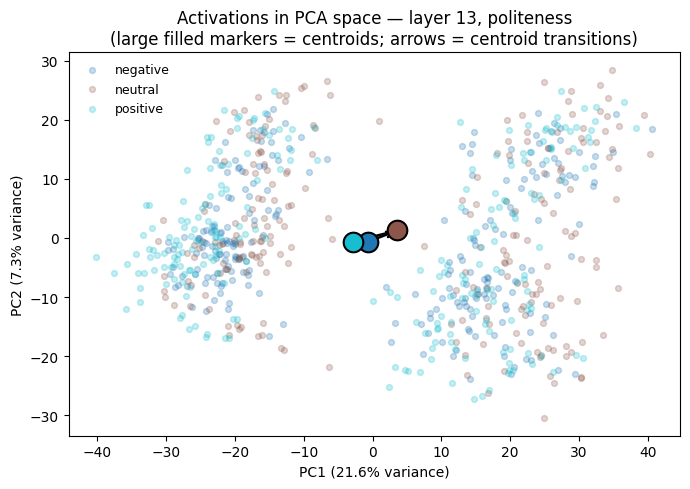

In [ ]:
from sklearn.decomposition import PCA

_all_vecs = np.stack([v.numpy() for lvl in levels_present for v in abl_13[lvl]])
_all_lbls = [lvl for lvl in levels_present for _ in abl_13[lvl]]

_pca = PCA(n_components=2)
_coords = _pca.fit_transform(_all_vecs)
_var = _pca.explained_variance_ratio_

_centroids_2d = np.stack([
    _coords[[i for i, l in enumerate(_all_lbls) if l == lvl]].mean(0)
    for lvl in levels_present
])

ffig, ax = plt.subplots(figsize=(7, 5))

# Standard categorical palette
_palette = plt.cm.tab10(np.linspace(0, 1, len(levels_present)))

for k, lvl in enumerate(levels_present):
    _idx = [i for i, l in enumerate(_all_lbls) if l == lvl]
    ax.scatter(
        _coords[_idx, 0],
        _coords[_idx, 1],
        alpha=0.25,
        s=18,
        color=_palette[k],
        label=lvl
    )
    ax.scatter(
        *_centroids_2d[k],
        s=200,
        color=_palette[k],
        edgecolors="black",
        linewidths=1.5,
        zorder=5
    )

for i in range(len(levels_present) - 1):
    ax.annotate('', xy=_centroids_2d[i + 1], xytext=_centroids_2d[i],
                arrowprops=dict(arrowstyle='->', color='black', lw=1.8))

ax.set_xlabel(f'PC1 ({_var[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({_var[1]:.1%} variance)')
ax.set_title(f'Activations in PCA space — layer {LAYER}, {TRAIT}\n'
             f'(large filled markers = centroids; arrows = centroid transitions)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 Label-Permutation Null Test

**Purpose:** verify that the strong metric values are not an artifact of the high-dimensional geometry or a quirk of the sample set.

**Method:** shuffle the intensity labels randomly 100 times (keeping activation vectors fixed) and recompute all five metrics each time. This constructs an empirical null distribution — the values we would expect if label assignment were meaningless.

**Reading the output:**
- Console prints `obs`, null `μ ± σ`, and `p(null ≥ obs)` for each metric.
- A p-value near 0 means no permutation matched or exceeded the observed value → the structure is real.
- For `midpoint_residual`, lower is better, so the test is reversed: `p(null ≤ obs)` is reported.

**Reading the histograms:**
- Gray bars = null distribution.
- Red vertical line = observed value at layer 13.
- A line far outside the histogram bulk confirms statistical significance.

Label-permutation null (n=100) vs. observed at layer 13:
              spearman: obs=+0.8475  null μ=+0.1730 σ=0.0348  p(null>=obs)=0.000
               kendall: obs=+0.7069  null μ=+0.1335 σ=0.0269  p(null>=obs)=0.000
              probe_r2: obs=+0.8198  null μ=-1.1289 σ=0.1887  p(null>=obs)=0.000
     midpoint_residual: obs=+0.6744  null μ=+0.9244 σ=0.2294  p(null<=obs)=0.120
              pc1_frac: obs=+0.6708  null μ=+0.6461 σ=0.0706  p(null>=obs)=0.340


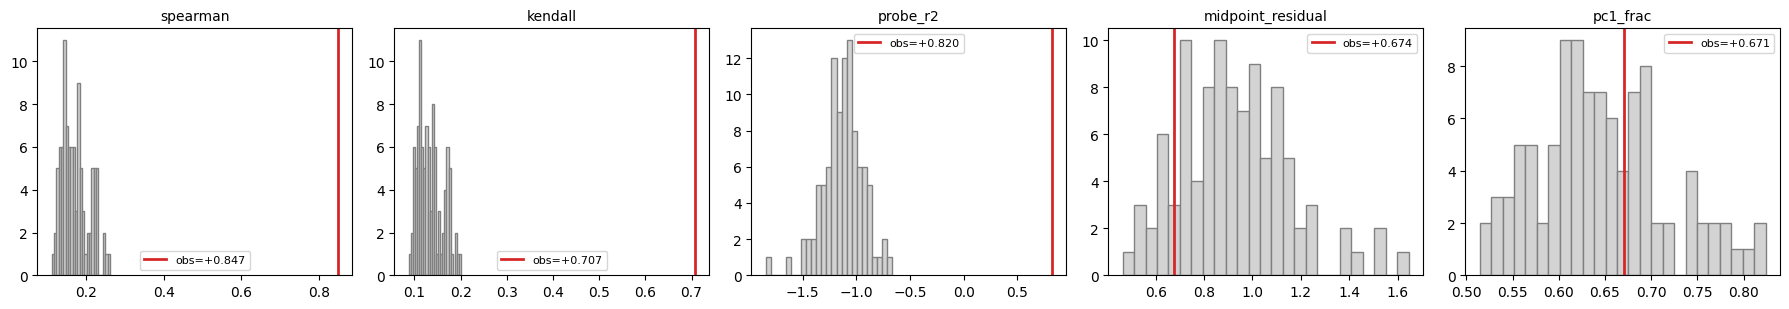

In [ ]:
N_PERM = 100
PERM_SEED = 13
_rng = np.random.default_rng(PERM_SEED)

flat_vecs = [v for lvl in levels_present for v in abl_13[lvl]]
sizes = [len(abl_13[lvl]) for lvl in levels_present]
null = {k: [] for k in metrics_13}
for _ in range(N_PERM):
    perm = _rng.permutation(len(flat_vecs))
    permuted = {}
    start = 0
    for lvl, sz in zip(levels_present, sizes):
        permuted[lvl] = [flat_vecs[perm[i]] for i in range(start, start + sz)]
        start += sz
    m = ordinal_linearity_metrics(permuted, levels_present)
    for k in null:
        null[k].append(m[k])
null = {k: np.array(v) for k, v in null.items()}

print(f'Label-permutation null (n={N_PERM}) vs. observed at layer {LAYER}:')
for k, obs in metrics_13.items():
    if np.isnan(obs):
        print(f'  {k:>20}: n/a')
        continue
    if k == 'midpoint_residual':
        p = float((null[k] <= obs).mean()); tail = '<='
    else:
        p = float((null[k] >= obs).mean()); tail = '>='
    print(f'  {k:>20}: obs={obs:+.4f}  null μ={null[k].mean():+.4f} σ={null[k].std():.4f}  '
          f'p(null{tail}obs)={p:.3f}')

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, (k, obs) in zip(axes, metrics_13.items()):
    if np.isnan(obs):
        ax.set_title(f'{k}\n(n/a)'); ax.axis('off'); continue
    ax.hist(null[k], bins=25, color='lightgray', edgecolor='gray')
    ax.axvline(obs, color='C3', linewidth=2, label=f'obs={obs:+.3f}')
    ax.set_title(k, fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 5.4 Metrics Across Layers 8–22

Repeat all five metrics at each layer in the sweep range, using activations already extracted in §3.4.

**What to look for in each panel:**
- **Spearman / Kendall / probe_r²:** a peak at a specific layer range identifies where intensity information is most cleanly linearly encoded. A broad plateau means the structure is distributed across many layers.
- **Midpoint residual:** a trough (minimum) marks the layer where neutral is most evenly spaced between the extremes.
- **PC1 fraction:** plateau near 1.0 across layers → the centroid geometry is robustly one-dimensional throughout the network.

The gray dotted vertical line marks layer 13 (focal layer), so you can see whether it is a local optimum or an arbitrary choice.

/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.35882482622219e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.247889209973437e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.51753591493798e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/Users/francescobraicovi

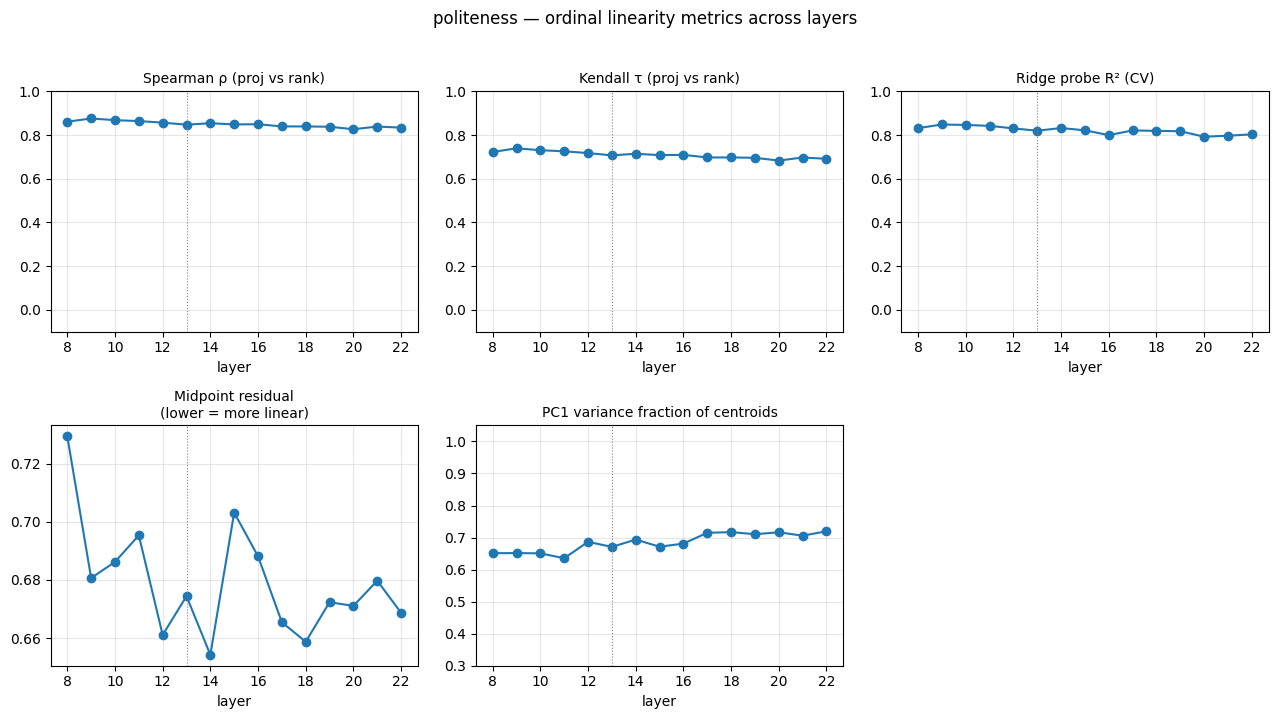

In [ ]:
sweep_results = {k: [] for k in metrics_13}
for layer in sweep_layers:
    acts_layer = {(t, i, s): v for (t, i, s, l), v in acts_all.items() if l == layer}
    abl = acts_by_level_from_dict(acts_layer, levels_present)
    m = ordinal_linearity_metrics(abl, levels_present)
    for k in sweep_results:
        sweep_results[k].append(m[k])

panel_info = [
    ('spearman', 'Spearman ρ (proj vs rank)', (-0.1, 1.0)),
    ('kendall', 'Kendall τ (proj vs rank)', (-0.1, 1.0)),
    ('probe_r2', 'Ridge probe R² (CV)', (-0.1, 1.0)),
    ('midpoint_residual', 'Midpoint residual\n(lower = more linear)', None),
    ('pc1_frac', 'PC1 variance fraction of centroids', (0.3, 1.05)),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (key, title, ylim) in zip(axes.flat, panel_info):
    ax.plot(sweep_layers, sweep_results[key], marker='o', linewidth=1.5)
    ax.axvline(LAYER, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('layer')
    ax.set_title(title, fontsize=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
axes.flat[5].axis('off')
fig.suptitle(f'{TRAIT} — ordinal linearity metrics across layers', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 6. Sparse Autoencoder (SAE) Analysis

**Motivation:** The dense residual stream is polysemantic — many concepts are superimposed in the same 2304-dimensional vector. A Sparse Autoencoder (SAE) decomposes the residual stream into a dictionary of discrete, largely monosemantic *features*, each firing for a specific concept.

**What is an SAE?**  
A two-layer bottleneck network (encoder → JumpReLU → decoder) trained to reconstruct the residual stream using a *sparse* linear combination of `d_sae` learned feature vectors. If feature `i` is active for a token, that token's meaning is partially explained by feature `i`.

**Why re-run the analysis on SAE codes?**  
If politeness linearity is a genuine semantic property, it should survive the sparse decomposition — and may even appear *more* clearly, since polysemantic interference is removed. If SAE metrics are much lower than dense metrics, the linear structure lives in the entangled residual but not in identifiable features.

**Gemma Scope SAEs** (used here) are pre-trained canonical SAEs released for every layer of `gemma-2-2b`, publicly available via `sae_lens`.

**Notation:**
- `d_sae = 16384`: dictionary size (vs. `d_in = 2304` raw dimensions)
- `L0`: mean number of *active* (non-zero) features per content token — sparsity diagnostic. Typical Gemma Scope values: 50–100.

### SAE Loading Utilities

Two functions used throughout §6:

- **`load_gemma_scope_sae(layer, device, width)`** — downloads the canonical Gemma Scope SAE for the given layer from HuggingFace via `sae_lens` and returns it in eval mode. Requires `sae_lens >= 5.0`.
- **`encode_with_sae_one_layer(samples, model, tokenizer, layer, sae, device)`** — runs the model forward pass, intercepts the residual stream at `layer`, encodes each token through the SAE, and mean-pools the sparse feature codes over content tokens (BOS/EOS/pad excluded). Returns the codes dict in the same `(trait, intensity, scenario_id) → tensor` format as `activations`, plus mean L0.

In [ ]:
# Requires sae-lens >= 5.0:  pip install sae-lens
from sae_lens import SAE


def load_gemma_scope_sae(layer: int, device: str, width: str = "16k"):
    """Load the canonical Gemma Scope residual-stream SAE for *layer*.

    Returns the SAE in eval mode on *device*. d_in matches gemma-2-2b's hidden_dim (2304).
    """
    sae = SAE.from_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_{width}/canonical",
        device=device,
    )
    sae.eval()
    return sae


def encode_with_sae_one_layer(
    samples, model, tokenizer, layer, sae, device, batch_size=8,
):
    """Run *model* on *samples*, encode per-token residuals at *layer* through *sae*,
    and mean-pool the sparse codes over content tokens (BOS/EOS/pad excluded).

    Returns
    -------
    codes : dict[(trait, intensity, scenario_id), tensor]
        Mean-pooled SAE codes, shape (d_sae,).
    mean_l0 : float
        Average active features per content token (sparsity check).
    """
    special_ids = {
        tid for tid in (tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id)
        if tid is not None
    }
    bucket = {}
    total_active = 0.0
    total_tokens = 0.0
    for start in range(0, len(samples), batch_size):
        batch = samples[start:start + batch_size]
        texts = [s.prompt for s in batch]
        enc = tokenizer(texts, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        resid = out.hidden_states[layer + 1]  # (B, L, D)

        token_ids = enc["input_ids"]
        attention_mask = enc["attention_mask"].bool()
        valid = attention_mask.clone()
        for sid in special_ids:
            valid &= token_ids != sid
        empty_rows = valid.sum(dim=1) == 0
        if empty_rows.any():
            valid[empty_rows] = attention_mask[empty_rows]
        weights = valid.to(resid.dtype).unsqueeze(-1)
        counts = weights.sum(dim=1).clamp(min=1)

        B, L, D = resid.shape
        with torch.no_grad():
            codes = sae.encode(resid.reshape(-1, D).to(sae.dtype))  # (B*L, F)
        codes = codes.reshape(B, L, -1).to(resid.dtype)

        active = (codes != 0).sum(dim=-1).float()  # (B, L)
        total_active += (active * valid.float()).sum().item()
        total_tokens += valid.sum().item()

        pooled = (codes * weights).sum(dim=1) / counts  # (B, F)
        pooled = pooled.detach().to("cpu", dtype=torch.float32)
        for i, sample in enumerate(batch):
            key = (sample.trait, sample.intensity, sample.scenario_id)
            bucket.setdefault(key, []).append(pooled[i])

    codes_dict = {k: torch.stack(v).mean(dim=0) for k, v in bucket.items()}
    mean_l0 = total_active / max(1.0, total_tokens)
    return codes_dict, mean_l0


SAE_WIDTH = "16k"

### 6.1 SAE Metrics at Layer 13

Load the Gemma Scope SAE for layer 13, encode all samples, and compute the same five linearity metrics on the resulting 16k-dimensional sparse codes.

**L0 check:** print confirms average active features per token. Values far outside 50–100 suggest the wrong SAE or a tokenization mismatch.

**How to read the comparison table:**
- Each row: `SAE value` then `(dense: value)`.
- Values close between SAE and dense → the linear structure is preserved in the sparse decomposition; the trait is encoded in identifiable features.
- SAE slightly below dense is expected — sparsity introduces quantization noise.
- A large drop (>0.1) would suggest the linear ordering exists only in the superimposed residual, not in individual features.

In [ ]:
sae_13 = load_gemma_scope_sae(LAYER, device, SAE_WIDTH)
print(f'Loaded SAE  layer={LAYER}  width={SAE_WIDTH}  d_in={sae_13.cfg.d_in}  d_sae={sae_13.cfg.d_sae}')

sae_acts_13, sae_l0_13 = encode_with_sae_one_layer(
    samples, model, tokenizer, LAYER, sae_13, device
)
sae_abl_13 = acts_by_level_from_dict(sae_acts_13, levels_present)
print(f'Mean per-token L0 (active features / token): {sae_l0_13:.1f}')

sae_metrics_13 = ordinal_linearity_metrics(sae_abl_13, levels_present)
print(f'\nLayer {LAYER} — SAE (sparse) linearity metrics:')
for k, v in sae_metrics_13.items():
    print(f'  {k:>20}: {v:+.4f}      (dense: {metrics_13[k]:+.4f})')

Loaded SAE  layer=13  width=16k  d_in=2304  d_sae=16384
Mean per-token L0 (active features / token): 77.3

Layer 13 — SAE (sparse) linearity metrics:
              spearman: +0.7742      (dense: +0.8475)
               kendall: +0.6302      (dense: +0.7069)
              probe_r2: +0.8480      (dense: +0.8198)
     midpoint_residual: +0.6358      (dense: +0.6744)
              pc1_frac: +0.6562      (dense: +0.6708)


### 6.2 Difference-Vector Heatmap: Dense vs. SAE

Side-by-side cosine similarity matrices for (a) dense residual vectors and (b) SAE feature codes at layer 13.

**What to compare:**
- Are the off-diagonal values similar between the two panels?
- Higher off-diagonal in SAE → direction alignment is *cleaner* in sparse feature space.
- Lower off-diagonal in SAE → sparsity disrupts the geometric structure of the transitions.
- Near-identical matrices → the SAE faithfully preserves the activation geometry relevant to politeness.

SAE difference-vector cosine similarity matrix (layer 13, width 16k):
                         politeness:positive-neutralpoliteness:neutral-negativepoliteness:positive-negative
politeness:positive-neutral                     1.0000                    -0.2189                     0.5745
politeness:neutral-negative                    -0.2189                     1.0000                     0.6717
politeness:positive-negative                     0.5745                     0.6717                     1.0000


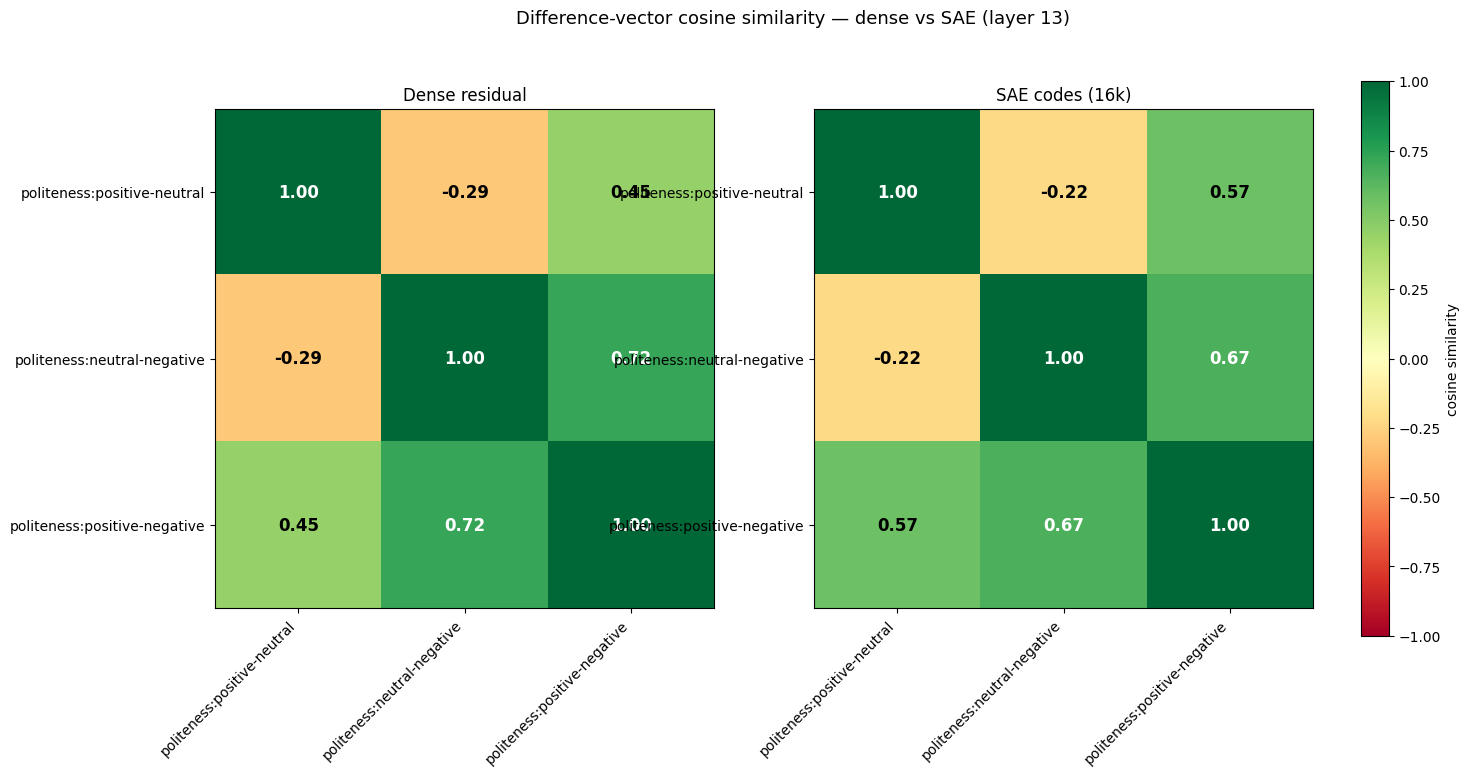

In [ ]:
sae_diffs_13 = compute_difference_vectors(sae_acts_13, TRAITS_CFG)
sae_labels, sae_matrix = similarity_matrix(sae_diffs_13)

print(f'SAE difference-vector cosine similarity matrix (layer {LAYER}, width {SAE_WIDTH}):')
header = f"{'':>25}" + "".join(f"{l:>27}" for l in sae_labels)
print(header)
for i, li in enumerate(sae_labels):
    row = f"{li:>25}" + "".join(f"{sae_matrix[i, j]:>27.4f}" for j in range(len(sae_labels)))
    print(row)

n = len(sae_labels)
cell = 2.4
fig, axes = plt.subplots(1, 2, figsize=(max(13, n * cell * 2 + 1), max(5, n * cell)))
for ax, mat, title in zip(axes, [matrix, sae_matrix], ['Dense residual', f'SAE codes ({SAE_WIDTH})']):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(sae_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(sae_labels, fontsize=10)
    for i, j in itertools.product(range(n), range(n)):
        color = 'white' if abs(mat[i, j]) > 0.65 else 'black'
        ax.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)
    ax.set_title(title, fontsize=12)
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.04, pad=0.04, label='cosine similarity')
fig.suptitle(f'Difference-vector cosine similarity — dense vs SAE (layer {LAYER})', fontsize=13)
plt.show()

### 6.3 Permutation Test on SAE Codes

Same label-permutation test as §5.2, applied to SAE activations.

**Reading the histograms:**
- Gray bars = SAE null distribution.
- **Red line** = SAE observed value.
- **Blue dashed line** = dense observed value (from §5.2), overlaid for direct comparison.

If both lines are far outside the null bulk, both representations encode a real structure. The gap between red and blue lines shows whether SAE is more or less decodable than the dense residual stream at this layer.

SAE label-permutation null (n=100) vs. observed at layer 13:
              spearman: obs=+0.7742  null μ=+0.1703 σ=0.0515  p(null>=obs)=0.000
               kendall: obs=+0.6302  null μ=+0.1316 σ=0.0401  p(null>=obs)=0.000
              probe_r2: obs=+0.8480  null μ=-0.7360 σ=0.1204  p(null>=obs)=0.000
     midpoint_residual: obs=+0.6358  null μ=+0.9321 σ=0.2638  p(null<=obs)=0.100
              pc1_frac: obs=+0.6562  null μ=+0.6564 σ=0.0782  p(null>=obs)=0.470


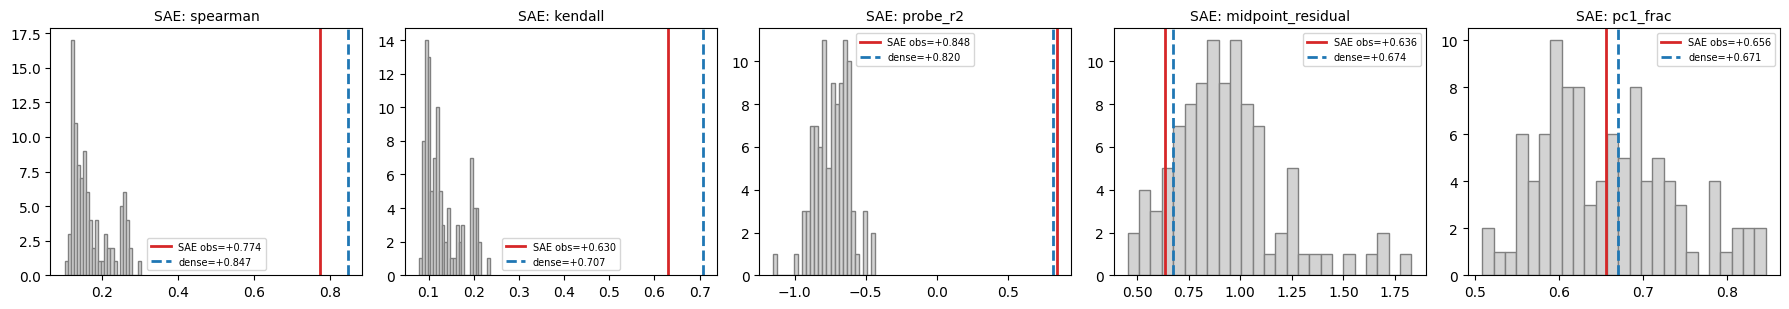

In [ ]:
sae_flat = [v for lvl in levels_present for v in sae_abl_13[lvl]]
sae_sizes = [len(sae_abl_13[lvl]) for lvl in levels_present]
sae_rng = np.random.default_rng(PERM_SEED)
sae_null = {k: [] for k in sae_metrics_13}
for _ in range(N_PERM):
    perm = sae_rng.permutation(len(sae_flat))
    permuted = {}
    start = 0
    for lvl, sz in zip(levels_present, sae_sizes):
        permuted[lvl] = [sae_flat[perm[i]] for i in range(start, start + sz)]
        start += sz
    m = ordinal_linearity_metrics(permuted, levels_present)
    for k in sae_null:
        sae_null[k].append(m[k])
sae_null = {k: np.array(v) for k, v in sae_null.items()}

print(f'SAE label-permutation null (n={N_PERM}) vs. observed at layer {LAYER}:')
for k, obs in sae_metrics_13.items():
    if np.isnan(obs):
        print(f'  {k:>20}: n/a'); continue
    if k == 'midpoint_residual':
        p = float((sae_null[k] <= obs).mean()); tail = '<='
    else:
        p = float((sae_null[k] >= obs).mean()); tail = '>='
    print(f'  {k:>20}: obs={obs:+.4f}  null μ={sae_null[k].mean():+.4f} σ={sae_null[k].std():.4f}  '
          f'p(null{tail}obs)={p:.3f}')

fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
for ax, (k, obs) in zip(axes, sae_metrics_13.items()):
    if np.isnan(obs):
        ax.set_title(f'{k}\n(n/a)'); ax.axis('off'); continue
    ax.hist(sae_null[k], bins=25, color='lightgray', edgecolor='gray')
    ax.axvline(obs, color='C3', linewidth=2, label=f'SAE obs={obs:+.3f}')
    ax.axvline(metrics_13[k], color='C0', linewidth=2, linestyle='--', label=f'dense={metrics_13[k]:+.3f}')
    ax.set_title(f'SAE: {k}', fontsize=10)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6.4 SAE Metrics Across Layers 8–22

Load and run a fresh SAE for each layer in the sweep. Reports all five metrics and `L0` per layer.

**What to look for:**
- Do SAE metric peaks align with the dense metric peaks found in §5.4? Alignment supports the claim that linearity is a robust property of the network, not an artifact of representation format.
- Does `L0` vary systematically with depth? Large changes in sparsity across layers would complicate cross-layer comparisons.
- Layers where SAE metrics are close to dense metrics → those layers' linear structure is well-captured by identifiable features.

In [ ]:
sae_sweep_results = {k: [] for k in metrics_13}
sae_l0_per_layer = []
for layer in sweep_layers:
    sae = load_gemma_scope_sae(layer, device, SAE_WIDTH)
    sae_acts_layer, l0_layer = encode_with_sae_one_layer(
        samples, model, tokenizer, layer, sae, device
    )
    sae_abl_layer = acts_by_level_from_dict(sae_acts_layer, levels_present)
    m = ordinal_linearity_metrics(sae_abl_layer, levels_present)
    for k in sae_sweep_results:
        sae_sweep_results[k].append(m[k])
    sae_l0_per_layer.append(l0_layer)
    print(f'layer {layer:2d}  L0={l0_layer:5.1f}  ' +
          '  '.join(f'{k}={sae_sweep_results[k][-1]:+.3f}' for k in sae_sweep_results))
    del sae
    if device == 'cuda':
        torch.cuda.empty_cache()
    elif device == 'mps':
        torch.mps.empty_cache()

layer  8  L0= 77.3  spearman=+0.837  kendall=+0.695  probe_r2=+0.844  midpoint_residual=+0.750  pc1_frac=+0.639
layer  9  L0= 77.2  spearman=+0.862  kendall=+0.723  probe_r2=+0.847  midpoint_residual=+0.630  pc1_frac=+0.654
layer 10  L0= 78.8  spearman=+0.836  kendall=+0.695  probe_r2=+0.851  midpoint_residual=+0.662  pc1_frac=+0.638
layer 11  L0= 76.3  spearman=+0.800  kendall=+0.656  probe_r2=+0.851  midpoint_residual=+0.728  pc1_frac=+0.586
layer 12  L0= 78.3  spearman=+0.815  kendall=+0.671  probe_r2=+0.858  midpoint_residual=+0.571  pc1_frac=+0.716
layer 13  L0= 77.3  spearman=+0.774  kendall=+0.630  probe_r2=+0.848  midpoint_residual=+0.636  pc1_frac=+0.656
layer 14  L0= 76.0  spearman=+0.795  kendall=+0.650  probe_r2=+0.843  midpoint_residual=+0.575  pc1_frac=+0.710


/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/Users/francescobraicovich/Documents/Progetti/Bocconi/llm-behaviour-intensity-representation/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:267: UserWarning: Sing

layer 15  L0= 71.4  spearman=+0.797  kendall=+0.653  probe_r2=+0.835  midpoint_residual=+0.696  pc1_frac=+0.624


KeyboardInterrupt: 

### 6.5 Master Comparison: Dense vs. SAE Across All Layers

Six-panel figure combining all sweep results:

- **Panels 1–5:** each linearity metric plotted for dense residual (circles) and SAE codes (squares) across layers 8–22. The gray dotted vertical line marks layer 13.
- **Panel 6:** SAE L0 per layer — confirms sparsity is stable across the sweep (no collapse or explosion at any specific layer).

**How to read it:**
- Solid circles = dense; open squares = SAE.
- Close tracking between the two series → the metric is robust to representation format.
- Divergence at specific layers → those layers encode politeness differently in raw activation space vs. sparse feature space.
- A consistent gap (SAE slightly below dense) across all layers is expected and acceptable.

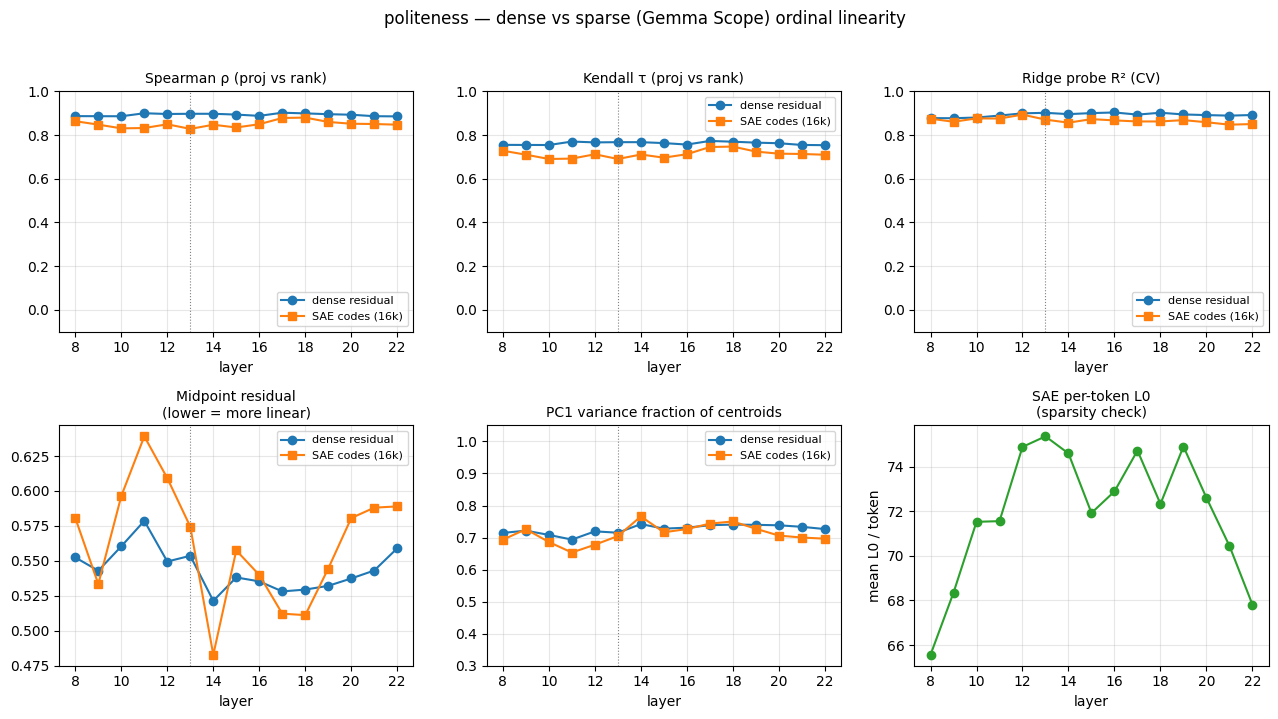

In [ ]:
panel_info_sae = [
    ('spearman', 'Spearman ρ (proj vs rank)', (-0.1, 1.0)),
    ('kendall', 'Kendall τ (proj vs rank)', (-0.1, 1.0)),
    ('probe_r2', 'Ridge probe R² (CV)', (-0.1, 1.0)),
    ('midpoint_residual', 'Midpoint residual\n(lower = more linear)', None),
    ('pc1_frac', 'PC1 variance fraction of centroids', (0.3, 1.05)),
]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (key, title, ylim) in zip(axes.flat, panel_info_sae):
    ax.plot(sweep_layers, sweep_results[key], marker='o', linewidth=1.5, label='dense residual')
    ax.plot(sweep_layers, sae_sweep_results[key], marker='s', linewidth=1.5, label=f'SAE codes ({SAE_WIDTH})')
    ax.axvline(LAYER, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('layer')
    ax.set_title(title, fontsize=10)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes.flat[5].plot(sweep_layers, sae_l0_per_layer, marker='o', linewidth=1.5, color='C2')
axes.flat[5].set_xlabel('layer')
axes.flat[5].set_ylabel('mean L0 / token')
axes.flat[5].set_title('SAE per-token L0\n(sparsity check)', fontsize=10)
axes.flat[5].grid(alpha=0.3)
fig.suptitle(f'{TRAIT} — dense vs sparse (Gemma Scope) ordinal linearity', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Summary of Findings

### How to read the results

Each section answers a distinct question about the geometry; together they form a profile of how the model encodes the trait. Use this map when interpreting the numbers:

| Question | Where to look | What the metric tells you |
|----------|--------------|---------------------------|
| Is the trait linearly *decodable* from activations? | §5.1 `spearman`, `probe_r2` | High → a linear projection recovers the ordinal rank; the information is present and linearly accessible. |
| Are consecutive transitions geometrically aligned? | §3.2 / §3.3 adjacent-step cosine | Near +1 → the two steps point the same way (uniform 1D axis). Near 0 → ordered but not along a single ray. |
| Is the alignment robust to the choice of ruler? | §3.5 whitened + disattenuated cosines | If the Euclidean value is misleading, Park / Mahalanobis whitening or disattenuation will lift it. If all four agree, the geometry is what it appears to be. |
| Is the centroid geometry 1D? | §5.1 `pc1_frac` | Near 1 → centroids essentially collinear; near 0.33 → spread across three independent directions. |
| Is `neutral` evenly spaced between the extremes? | §5.1 `midpoint_residual` | Near 0 → uniform spacing; near 1 → neutral is displaced toward one extreme. |
| Is the structure statistically significant? | §5.3 permutation null | `p ≈ 0` for all metrics → the structure cannot be explained by chance label assignment. |
| Does the structure survive SAE decomposition? | §6.1 / §6.5 SAE-vs-dense gap | Small gap → the trait is encoded in identifiable sparse features. Large drop → it lives in polysemantic superposition only. |

### How the metrics combine

- **High decodability + high adjacent-step cosine + low midpoint residual** → a clean 1D linear encoding: equal intensity steps map to equal displacements along one direction.
- **High decodability + near-zero adjacent-step cosine** → an *ordered but curved* manifold: the model ranks the levels correctly but consecutive transitions point in different directions. A linear probe still succeeds because the clusters are separable, even though the geometry is not a straight line.
- **Low decodability everywhere** → the trait is not linearly represented at this layer; check the layer sweep for a better candidate.
- **Dense and SAE metrics track closely across layers** → the linear structure is a property of identifiable features, not an artifact of representation format.

### Open questions to take into subsequent analyses

- Which specific SAE features activate differentially across intensity levels?
- Does the same pattern hold for other traits (aggressiveness, formality)?
- Is the geometry stable across paraphrase generation seeds, or sensitive to dataset particulars?